# Binary Classification Pipeline: Churn Prediction

- Phase 1: EDA & Audit
Data Quality: Document dtypes, ranges, and null-handling strategy for 20 features.

---

- Phase 2: Preprocessing

Splitting: Utilize pre-defined churn-80 and churn-20 sets.

---

- Phase 3: Architecture Experiments
Variant A: Shallow Wide (1 layer, 128 units, ReLU).

Variant B: Deep Narrow (4 layers, 32 units, ReLU).

Variant C: Activation Swap (Test tanh and LeakyReLU).

Logging: Provide training/validation loss curves and parameter counts for all.

---

- Phase 4: Optimization & Stability
Regularization: Implement Dropout and Batch Normalization.

Callbacks: Integrate Early Stopping and Learning Rate Reduction.

A/B Tests: Compare Weight Initialization and Optimizers (Adam, SGD, RMSprop).

---

- Phase 5: Imbalance Management
Baselines: Compare "Always No-Churn" accuracy against model performance.

Resampling: Implement Class Weights and SMOTE.

Thresholds: Plot Precision-Recall curve and justify an optimal decision threshold.

---

- Phase 6: Evaluation
Full Report: Per-class F1, ROC-AUC, and Confusion Matrix on the test set.

Calibration: Provide an ROC Curve overlay and a Reliability Diagram.

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve, f1_score
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
np.random.seed(42)
tf.random.set_seed(42)


## phase 1

In [157]:
import pandas as pd

test_df= pd.read_csv(r"Telecom_Churn\churn-bigml-20.csv")
train_df = pd.read_csv(r"Telecom_Churn\churn-bigml-80.csv")

In [158]:
def explore(df):
  
    # Shape
    print("\nShape:")
    print(df.shape)

    # Data Types
    print("\nData Types:")
    display(df.dtypes.to_frame(name='Data Type'))

    # Missing Values
    print("\nMissing Values:")
    display(df.isnull().sum().to_frame(name='Missing Count'))

    # Duplicates
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    # Numerical Summary
    print("\nNumerical Summary:")
    display(df.describe())

    # Categorical Columns
    cat_cols = df.select_dtypes(include=['object', 'bool']).columns

    print("\nCategorical Columns Distribution:")

    for col in cat_cols:
        print(f"\n--- {col} ---")
        display(df[col].value_counts().to_frame(name='Count'))
        print(f"num of unique values in {col}:is {df[col].nunique()} ")

In [159]:
print ("Explore train dataset")
explore(train_df)

Explore train dataset

Shape:
(2666, 20)

Data Types:


,Data Type
State,object
Account length,int64
Area code,int64
International plan,object
Voice mail plan,object
Number vmail messages,int64
Total day minutes,float64
Total day calls,int64
Total day charge,float64
Total eve minutes,float64



Missing Values:


,Missing Count
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0



Duplicate Rows:
0

Numerical Summary:


...

num of unique values in International plan:is 2 

--- Voice mail plan ---


,Count
Voice mail plan,
No,1933
Yes,733


num of unique values in Voice mail plan:is 2 

--- Churn ---


,Count
Churn,
False,2278
True,388


num of unique values in Churn:is 2 


In [160]:
print ("Explore test dataset")
explore(test_df)

Explore test dataset

Shape:
(667, 20)

Data Types:


,Data Type
State,object
Account length,int64
Area code,int64
International plan,object
Voice mail plan,object
Number vmail messages,int64
Total day minutes,float64
Total day calls,int64
Total day charge,float64
Total eve minutes,float64



Missing Values:


,Missing Count
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0



Duplicate Rows:
0

Numerical Summary:


...

num of unique values in International plan:is 2 

--- Voice mail plan ---


,Count
Voice mail plan,
No,478
Yes,189


num of unique values in Voice mail plan:is 2 

--- Churn ---


,Count
Churn,
False,572
True,95


num of unique values in Churn:is 2 


## phase 2

In [161]:
train_df['Area code'].value_counts()

Area code
415    1318
510     679
408     669
Name: count, dtype: int64

In [162]:
pd.crosstab(
    train_df['Area code'],
    train_df['Churn'],
    normalize='index'
)

Churn,False,True
Area code,,
408,0.859492,0.140508
415,0.852049,0.147951
510,0.854197,0.145803


area code has small number of values and don't effect the target so we can drop it

In [163]:
train_df.drop(columns=['Area code'], inplace=True)
test_df.drop(columns=['Area code'], inplace=True)

In [164]:
## encoding
binary_map = {
    'Yes': 1,
    'No': 0,
    True: 1,
    False: 0
}

binary_cols = [
    'International plan',
    'Voice mail plan',
    'Churn'
]

for col in binary_cols:
    train_df[col] = train_df[col].map(binary_map)
    test_df[col] = test_df[col].map(binary_map)

## one hot encoding for the state
train_df = pd.get_dummies(
    train_df,
    columns=['State'],
    drop_first=True
)

test_df = pd.get_dummies(
    test_df,
    columns=['State'],
    drop_first=True
)
bool_cols = train_df.select_dtypes(include='bool').columns

train_df[bool_cols] = train_df[bool_cols].astype(int)
test_df[bool_cols] = test_df[bool_cols].astype(int)

In [165]:
train_df, test_df = train_df.align(
    test_df,
    join='left',
    axis=1,
    fill_value=0
)

In [166]:
train_df.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,...,0,0,0,0,0,0,0,0,0,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,...,0,0,0,0,0,0,0,0,0,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,...,0,0,0,0,0,0,0,0,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,...,0,0,0,0,0,0,0,0,0,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,...,0,0,0,0,0,0,0,0,0,0


In [167]:
## data splitting
X_train_raw = train_df.drop('Churn', axis=1).values
y_train_raw = train_df['Churn'].values

X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']

In [168]:
## validation split 
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_raw, y_train_raw, test_size=0.15, stratify=y_train_raw, random_state=42
)

In [169]:
## scaling 
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

c:\Users\habib\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## Phase 3

In [170]:

# A helper function for training the model, plotting the loss curve, and printing the number of parameters
def run_experiment(model, model_name, X_train, y_train, X_val, y_val, epochs=30, batch_size=32):
    # model compilation
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    # print the number of prameters and model summary
    print("\n" + "="*50)
    print(f" Experiment: {model_name}")
    print("="*50)
    model.summary()
    
    # model training
    history = model.fit(X_train, y_train, 
                        validation_data=(X_val, y_val), 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        verbose=1)
    
    # plotting training & validation loss curves
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return history

input_shape = X_tr_scaled.shape[1]


 Experiment: Variant A: Shallow Wide


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_136 (Dense)               │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_137 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8447 - loss: 0.3943 - val_accuracy: 0.8525 - val_loss: 0.3923
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8764 - loss: 0.3108 - val_accuracy: 0.8525 - val_loss: 0.3940
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8808 - loss: 0.2864 - val_accuracy: 0.8475 - val_loss: 0.4012
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8866 - loss: 0.2693 - val_accuracy: 0.8475 - val_loss: 0.4048
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8963 - loss: 0.2542 - val_accuracy: 0.8525 - val_loss: 0.4048
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9069 - loss: 0.2390 - val_accuracy: 0.8575 - val_loss: 0.4020
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9135 - loss: 0.2237 - val_accuracy: 0.8575 - val_loss: 0.3972
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9210 - loss: 0.2086 - val_accuracy: 0.8575 - val_loss:

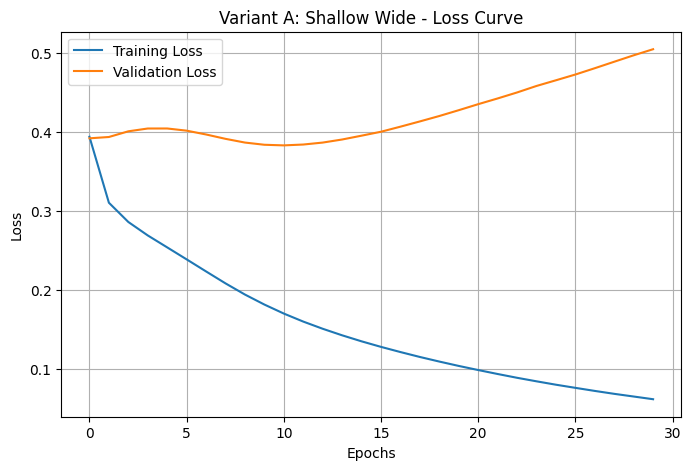

In [171]:
# model A "one wide layer"
model_A = models.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # output layer 
])

history_A = run_experiment(model_A, "Variant A: Shallow Wide", X_tr_scaled, y_tr, X_val_scaled, y_val)


 Experiment: Variant B: Deep Narrow


Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_138 (Dense)               │ (None, 32)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_140 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_141 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_142 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7811 - loss: 0.5052 - val_accuracy: 0.8550 - val_loss: 0.4114
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8544 - loss: 0.3821 - val_accuracy: 0.8550 - val_loss: 0.3966
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8544 - loss: 0.3379 - val_accuracy: 0.8575 - val_loss: 0.4017
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8641 - loss: 0.3051 - val_accuracy: 0.8475 - val_loss: 0.4212
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8804 - loss: 0.2832 - val_accuracy: 0.8250 - val_loss: 0.4426
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8901 - loss: 0.2654 - val_accuracy: 0.8200 - val_loss: 0.4592
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8945 - loss: 0.2499 - val_accuracy: 0.8150 - val_loss: 0.4776
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9007 - loss: 0.2345 - val_accuracy: 0.8125 - val_loss:

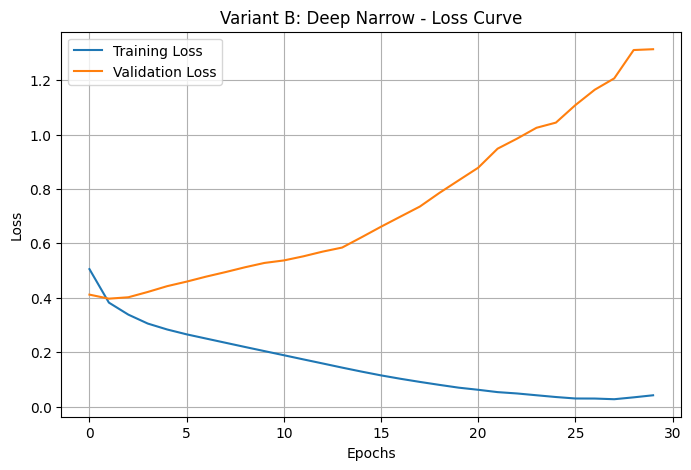

In [172]:
# model B 4 layers
model_B = models.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

history_B = run_experiment(model_B, "Variant B: Deep Narrow", X_tr_scaled, y_tr, X_val_scaled, y_val)


 Experiment: Variant C1: Tanh Swap


Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_143 (Dense)               │ (None, 32)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_144 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_145 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6981 - loss: 0.5909 - val_accuracy: 0.7825 - val_loss: 0.4951
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8676 - loss: 0.3939 - val_accuracy: 0.8450 - val_loss: 0.3923
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8808 - loss: 0.3154 - val_accuracy: 0.8450 - val_loss: 0.3866
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8848 - loss: 0.2924 - val_accuracy: 0.8400 - val_loss: 0.3987
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8870 - loss: 0.2815 - val_accuracy: 0.8400 - val_loss: 0.4076
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8910 - loss: 0.2729 - val_accuracy: 0.8400 - val_loss: 0.4137
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8936 - loss: 0.2649 - val_accuracy: 0.8375 - val_loss: 0.4183
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8967 - loss: 0.2569 - val_accuracy: 0.8425 - val_loss:

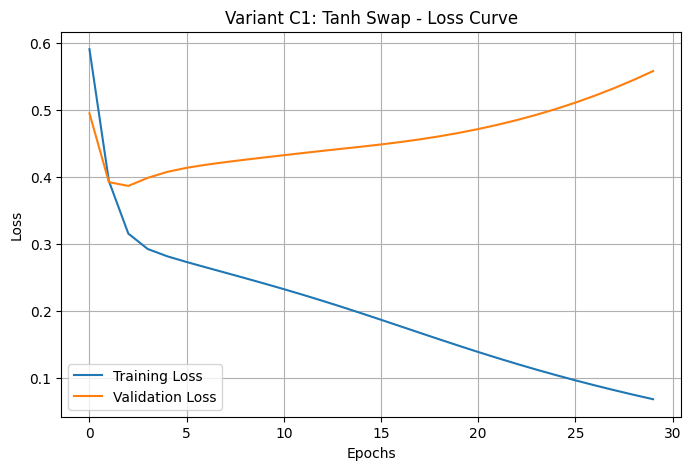

In [173]:
# tanh model
model_C_tanh = models.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(32, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

history_C_tanh = run_experiment(model_C_tanh, "Variant C1: Tanh Swap", X_tr_scaled, y_tr, X_val_scaled, y_val)


 Experiment: Variant C2: LeakyReLU Swap


Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_146 (Dense)               │ (None, 32)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_147 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8169 - loss: 0.4766 - val_accuracy: 0.8550 - val_loss: 0.4241
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8557 - loss: 0.3759 - val_accuracy: 0.8575 - val_loss: 0.4012
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8641 - loss: 0.3355 - val_accuracy: 0.8625 - val_loss: 0.3975
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8769 - loss: 0.3070 - val_accuracy: 0.8500 - val_loss: 0.4039
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8808 - loss: 0.2864 - val_accuracy: 0.8425 - val_loss: 0.4112
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8857 - loss: 0.2701 - val_accuracy: 0.8475 - val_loss: 0.4146
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8883 - loss: 0.2555 - val_accuracy: 0.8525 - val_loss: 0.4133
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8972 - loss: 0.2404 - val_accuracy: 0.8525 - val_loss:

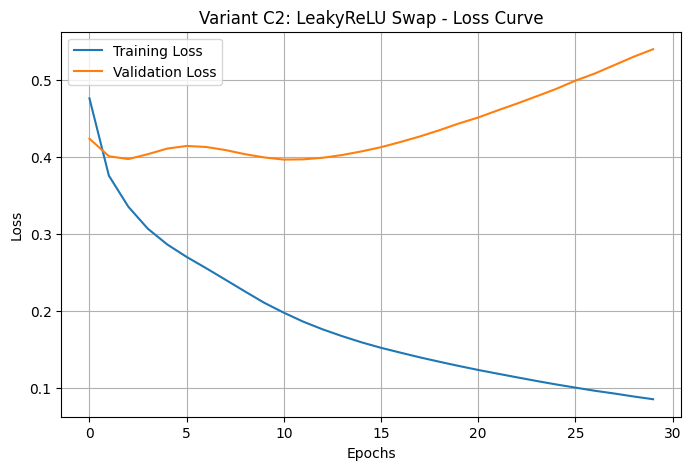

In [174]:
# leaky relu model
model_C_leaky = models.Sequential([
    layers.Input(shape=(input_shape,)),
    
    layers.Dense(32),
    layers.LeakyReLU(negative_slope=0.1),
    
    layers.Dense(32),
    layers.LeakyReLU(negative_slope=0.1),
    
    layers.Dense(1, activation='sigmoid')
])

history_C_leaky = run_experiment(model_C_leaky, "Variant C2: LeakyReLU Swap", X_tr_scaled, y_tr, X_val_scaled, y_val)

## Phase 4

In [175]:
# helper function to test models with optimization and call backs
def run_optimization_experiment(model_builder, experiment_name, optimizer_name, X_train, y_train, X_val, y_val, epochs=50):
    # Build a new version of the model before each trial.
    model = model_builder()
    
    # intialize callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=5,             
        restore_best_weights=True 
    )
    
    lr_reduction = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2,            
        patience=3,            
        verbose=1
    )
    
    # compiling optimizers
    model.compile(optimizer=optimizer_name,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    print("\n" + "="*60)
    print(f" Running: {experiment_name} | Optimizer: {optimizer_name}")
    print("="*60)
    
    # trainnig with callbacks
    history = model.fit(X_train, y_train, 
                        validation_data=(X_val, y_val), 
                        epochs=epochs, 
                        batch_size=32, 
                        callbacks=[early_stopping, lr_reduction],
                        verbose=1)
    
    # plotting loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title(f'{experiment_name} ({optimizer_name}) - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return history

input_shape = X_tr_scaled.shape[1]


 Running: Optimized Model (Glorot Uniform) | Optimizer: adam
Epoch 1/50


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5530 - loss: 0.7677 - val_accuracy: 0.8100 - val_loss: 0.5490 - learning_rate: 0.0010
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6964 - loss: 0.5832 - val_accuracy: 0.8225 - val_loss: 0.4835 - learning_rate: 0.0010
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7868 - loss: 0.4801 - val_accuracy: 0.8375 - val_loss: 0.4263 - learning_rate: 0.0010
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8314 - loss: 0.4123 - val_accuracy: 0.8475 - val_loss: 0.3961 - learning_rate: 0.0010
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8438 - loss: 0.3880 - val_accuracy: 0.8550 - val_loss: 0.3827 - learning_rate: 0.0010
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8597 - loss: 0.3496 - val_accuracy: 0.8550 - val_loss: 0.3804 - learning_rate: 0.0010
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8760 - loss: 0.3269 - val_accuracy: 0.8575 - va

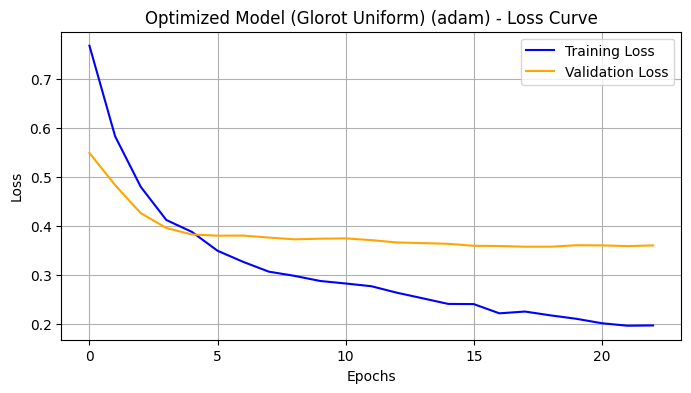


 Running: Optimized Model (He Normal) | Optimizer: rmsprop
Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6015 - loss: 0.7670 - val_accuracy: 0.6700 - val_loss: 0.6075 - learning_rate: 0.0010
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7140 - loss: 0.5743 - val_accuracy: 0.8350 - val_loss: 0.4494 - learning_rate: 0.0010
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8027 - loss: 0.4543 - val_accuracy: 0.8575 - val_loss: 0.3968 - learning_rate: 0.0010
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8336 - loss: 0.4077 - val_accuracy: 0.8575 - val_loss: 0.3900 - learning_rate: 0.0010
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8517 - loss: 0.3695 - val_accuracy: 0.8550 - val_loss: 0.3949 - learning_rate: 0.0010
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8588 - loss: 0.3602 - val_accuracy: 0.8575 - val_loss: 0.4013 - learning_rate: 0.0010
Epoch 7/50
63/71 ━━━━━━━━━━━━━━━━━━━━ 0s

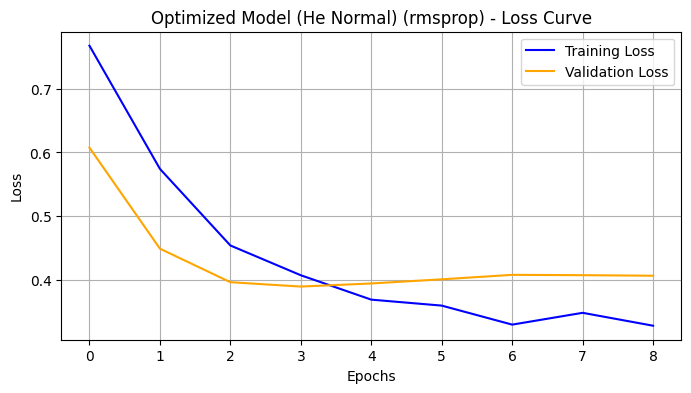


 Running: Optimized Model (Glorot Uniform) | Optimizer: <keras.src.optimizers.sgd.SGD object at 0x0000024B7EA5C190>
Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7524 - loss: 0.5300 - val_accuracy: 0.8550 - val_loss: 0.3985 - learning_rate: 0.0100
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 0.3766 - val_accuracy: 0.8550 - val_loss: 0.3836 - learning_rate: 0.0100
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8610 - loss: 0.3463 - val_accuracy: 0.8575 - val_loss: 0.3786 - learning_rate: 0.0100
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8716 - loss: 0.3296 - val_accuracy: 0.8600 - val_loss: 0.3835 - learning_rate: 0.0100
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8844 - loss: 0.3029 - val_accuracy: 0.8575 - val_loss: 0.3903 - learning_rate: 0.0100
Epoch 6/50
63/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8874 - loss: 0.2891
Epoch 6: ReduceLROnPlateau reducing learning rate

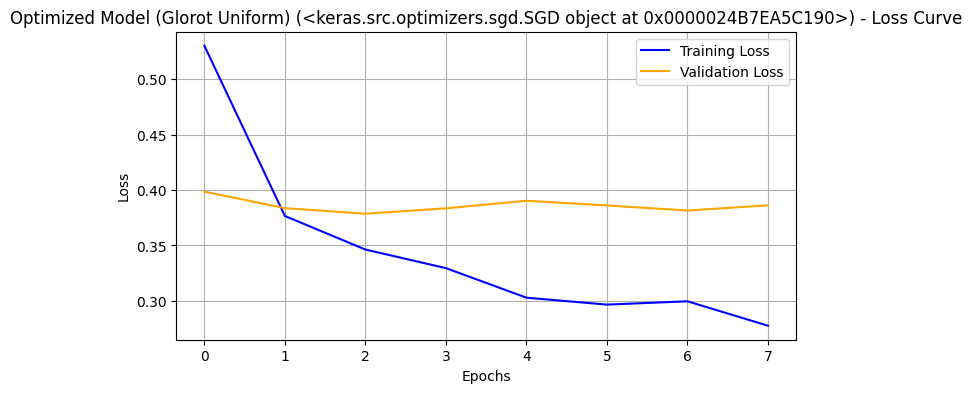

In [176]:
#  building the optimized base structure with Weight Initialization selection
def create_optimized_model(initializer='glorot_uniform'):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),
        
        # first layer
        layers.Dense(64, kernel_initializer=initializer, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # second layer
        layers.Dense(32, kernel_initializer=initializer, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # output layer
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# A/B Tests

# 1 Adam Optimizer with Glorot Uniform wights
history_adam = run_optimization_experiment(
    lambda: create_optimized_model(initializer='glorot_uniform'),
    experiment_name="Optimized Model (Glorot Uniform)",
    optimizer_name="adam",
    X_train=X_tr_scaled, y_train=y_tr, X_val=X_val_scaled, y_val=y_val
)

# 2 RMSprop Optimizer with He Normal weights
history_rmsprop = run_optimization_experiment(
    lambda: create_optimized_model(initializer='he_normal'),
    experiment_name="Optimized Model (He Normal)",
    optimizer_name="rmsprop",
    X_train=X_tr_scaled, y_train=y_tr, X_val=X_val_scaled, y_val=y_val
)

# 3 SGD Optimizer with Momentum weights
history_sgd = run_optimization_experiment(
    lambda: create_optimized_model(initializer='glorot_uniform'),
    experiment_name="Optimized Model (Glorot Uniform)",
    optimizer_name=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    X_train=X_tr_scaled, y_train=y_tr, X_val=X_val_scaled, y_val=y_val
)

## Phase 5

In [177]:
## baseline accurecy
no_churn_count = np.sum(y_val == 0) 
total_count = len(y_val)
baseline_accuracy = no_churn_count / total_count
print(f"1. Baseline accuracy: {baseline_accuracy:.4f}")

1. Baseline accuracy: 0.8550


In [178]:
# Class Weights 
classes = np.unique(y_tr)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)

class_weight_dict = {int(classes[i]): float(weights[i]) for i in range(len(classes))}

print(f"2. Calculated Class Weights: {class_weight_dict}")

2. Calculated Class Weights: {0: 0.5852272727272727, 1: 3.433333333333333}


In [179]:
# SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_scaled, y_tr)

print("Train shape after SMOTE:", X_tr_smote.shape)
print("Validation shape (Pure):", X_val_scaled.shape)

Train shape after SMOTE: (3872, 67)
Validation shape (Pure): (400, 67)


In [180]:
# using adam optimizer model
def build_base_model():
    return create_optimized_model(initializer='glorot_uniform')

# using class Weights
print("\n--- Training Model with Class Weights ---")
model_weighted = build_base_model()
model_weighted.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_weighted.fit(X_tr_scaled, y_tr, validation_data=(X_val_scaled, y_val), 
                   epochs=20, batch_size=32, class_weight=class_weight_dict, verbose=0)

# using SMOTE
print("--- Training Model with SMOTE ---")
model_smote = build_base_model()
model_smote.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_smote.fit(X_tr_smote, y_tr_smote, validation_data=(X_val_scaled, y_val), 
                 epochs=20, batch_size=32, verbose=0)

print("Training finished successfully!")


--- Training Model with Class Weights ---
--- Training Model with SMOTE ---
Training finished successfully!


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Optimal threshold for Class Weights model: 0.7361
Optimal threshold for SMOTE model: 0.3847


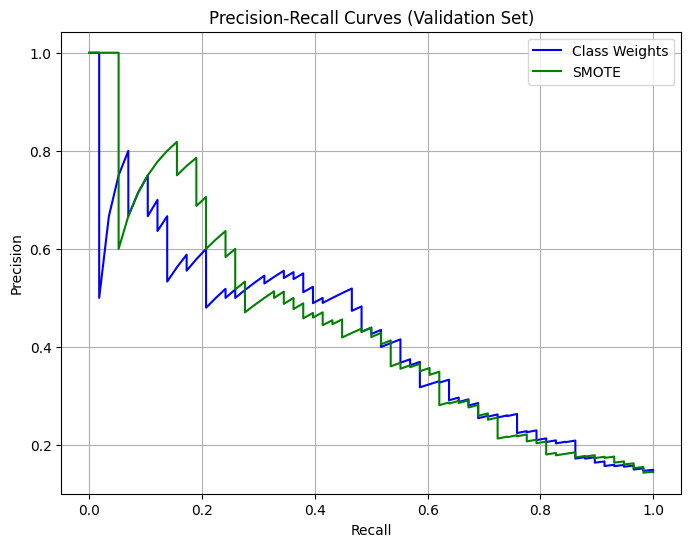

In [181]:
# Compute validation probabilities for both models
y_pred_prob_weighted = model_weighted.predict(X_val_scaled).ravel()
y_pred_prob_smote = model_smote.predict(X_val_scaled).ravel()

# Precision-Recall curves
precision_w, recall_w, thresholds_w = precision_recall_curve(y_val, y_pred_prob_weighted)
precision_s, recall_s, thresholds_s = precision_recall_curve(y_val, y_pred_prob_smote)

# Optimal thresholds per model (maximizing F1)
f1_w = 2 * precision_w * recall_w / (precision_w + recall_w + 1e-10)
best_thr_cw = thresholds_w[np.argmax(f1_w)]

f1_s = 2 * precision_s * recall_s / (precision_s + recall_s + 1e-10)
best_thr_smote = thresholds_s[np.argmax(f1_s)]

print(f"Optimal threshold for Class Weights model: {best_thr_cw:.4f}")
print(f"Optimal threshold for SMOTE model: {best_thr_smote:.4f}")

# Plot PR curves
plt.figure(figsize=(8, 6))
plt.plot(recall_w, precision_w, label='Class Weights', color='blue')
plt.plot(recall_s, precision_s, label='SMOTE', color='green')
plt.title('Precision-Recall Curves (Validation Set)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

In [182]:
from sklearn.metrics import classification_report

# Use each model's own optimal threshold
y_pred_weighted_class = (y_pred_prob_weighted >= best_thr_cw).astype(int)
y_pred_smote_class = (y_pred_prob_smote >= best_thr_smote).astype(int)

# Class Weights
print("="*60)
print(f"Metrics for Class Weights Model (Threshold = {best_thr_cw:.4f})")
print("="*60)
print(classification_report(y_val, y_pred_weighted_class, target_names=['No-Churn', 'Churn']))

# SMOTE
print("="*60)
print(f"Metrics for SMOTE Model (Threshold = {best_thr_smote:.4f})")
print("="*60)
print(classification_report(y_val, y_pred_smote_class, target_names=['No-Churn', 'Churn']))

Metrics for Class Weights Model (Threshold = 0.7361)
              precision    recall  f1-score   support

    No-Churn       0.91      0.93      0.92       342
       Churn       0.52      0.47      0.49        58

    accuracy                           0.86       400
   macro avg       0.72      0.70      0.70       400
weighted avg       0.85      0.86      0.86       400

Metrics for SMOTE Model (Threshold = 0.3847)
              precision    recall  f1-score   support

    No-Churn       0.92      0.88      0.90       342
       Churn       0.43      0.52      0.47        58

    accuracy                           0.83       400
   macro avg       0.67      0.70      0.68       400
weighted avg       0.84      0.83      0.84       400



## Phase 6

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.calibration import calibration_curve

# Use the SMOTE model (better performance) with its own optimal threshold
y_test_prob = model_smote.predict(X_test_scaled).ravel()
y_test_pred_class = (y_test_prob >= best_thr_smote).astype(int)

print("="*60)
print("PHASE 6: FINAL EVALUATION REPORT ON TEST SET")
print("="*60)
print(classification_report(y_test, y_test_pred_class, target_names=['No-Churn', 'Churn']))

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)
print(f"Final ROC-AUC Score: {roc_auc:.4f}")
print("="*60)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
PHASE 6: FINAL EVALUATION REPORT ON TEST SET
              precision    recall  f1-score   support

    No-Churn       0.94      0.90      0.92       572
       Churn       0.50      0.64      0.56        95

    accuracy                           0.86       667
   macro avg       0.72      0.77      0.74       667
weighted avg       0.88      0.86      0.87       667

Final ROC-AUC Score: 0.8427


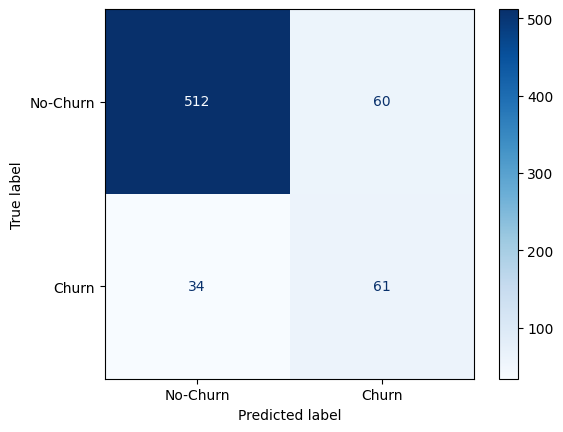

In [184]:
cm = confusion_matrix(y_test, y_test_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No-Churn', 'Churn'])
disp.plot(cmap='Blues')

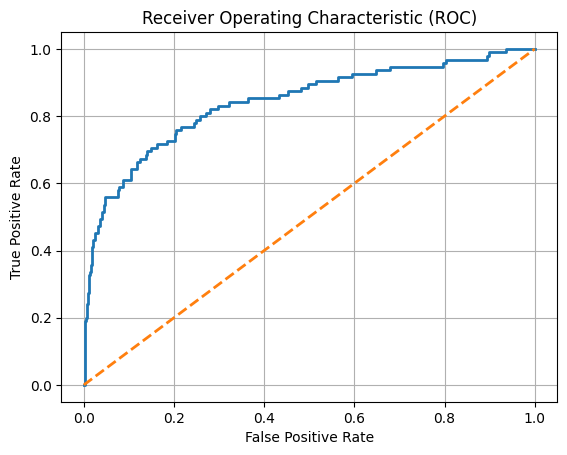

In [185]:
plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.grid(True)

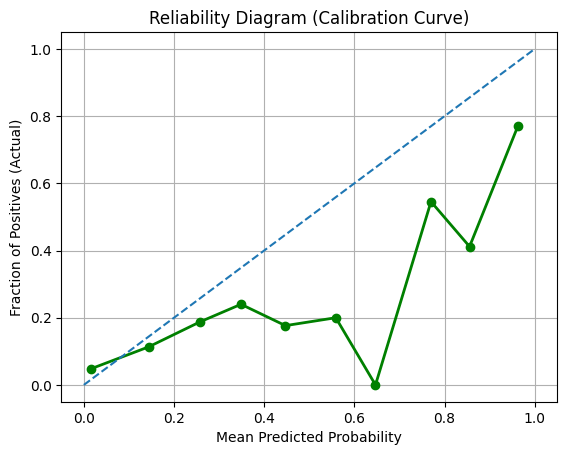

In [186]:
prob_true, prob_pred = calibration_curve(y_test, y_test_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='SMOTE Model', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Reliability Diagram (Calibration Curve)')
plt.grid(True)